In [1]:
############################# Cross Sections #############################
# The purpose of this notebook is to plot various cross-sections 
# of model output to characterize the domain and what is going 
# on.This notebook will look at a few corss sections in the 
# domine, plot averages, and potentially make movies of the 
# variables on interest. This notebook will include cross-
# sections of (1) salinity and temperature with density contours,
# (2) velocities, and (3) mixing and eddy viscosity/diffusivity.
#
# Notes:
# - This script runs in xroms 
# - This script heavily uses code from Dylan Schlichting 
# - 
#
########################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import warnings
import xarray as xr
import xroms
from matplotlib import ticker
crs = ccrs.PlateCarree()
from joblib import Parallel, delayed
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

## Define Functions  
Make functions to help with processing the output

In [3]:
# Make a function to open the model output
def open_roms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_netcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [4]:
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [5]:
# Make a function to calculate useful derivatives and add them back into 
# the dataset
def add_derivatives(ds, grid, q='salt'):
    '''
Analysis of velocity gradient tensor and frontogenesis function
following Hetland et al. (2025) JPO
    '''
    qs = ds[q]
    
    #############################
    # Flow and property gradients at the ocean surface
    
    ds['dqdx'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'X'), grid)    # defined at rho-points
    ds['dqdy'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'Y'), grid)    # defined at rho-points
    
    ds['dudx'] = grid.derivative(ds.isel(s_rho=-1).u, 'X', boundary='extend')  # defined at rho-points
    ds['dvdy'] = grid.derivative(ds.isel(s_rho=-1).v, 'Y', boundary='extend')  # defined at rho-points
    ds['dvdx'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).v, 'X', boundary='extend'), grid)  # defined at rho-points
    ds['dudy'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).u, 'Y', boundary='extend'), grid)  # defined at rho-points
    
    ###########################
    # Invariant flow properties
    
    # Vorticity:  v_x - u_y
    ds['zeta'] = (ds.dvdx - ds.dudy)/ds.f
    ds['zeta'].name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    ds['delta'] = (ds.dudx + ds.dvdy)/ds.f
    ds['delta'].name = 'Normalized divergence'

    # Major axis of deformation
    ds['alpha'] = ( np.sqrt( (ds.dudx-ds.dvdy)**2 + (ds.dvdx+ds.dudy)**2 ) )/ds.f
    ds['alpha'].name = 'Normalized total strain'

    ##################################
    # Principle deformation components

    ds['lminor'] = 0.5 * (ds.delta - ds.alpha)
    ds['lminor'].name = 'lambda minor'

    ds['lmajor'] = 0.5 * (ds.delta + ds.alpha)
    ds['lmajor'].name = 'lambda major'
    
    #############################################
    # Along- and cross-frontal velocity gradients
    
    # angle is wrt x, so need to do arctan2(y, x)
    ds['phi_cf'] = np.arctan2(ds.dqdy, ds.dqdx)
    ds['phi_af'] = ds.phi_cf + np.pi/2.0

    ds['du_cf'] = ( ds.dudx*np.cos(ds.phi_cf)**2 + ds.dvdy*np.sin(ds.phi_cf)**2 
               + (ds.dudy + ds.dvdx)*np.sin(ds.phi_cf)*np.cos(ds.phi_cf) )/ds.f

    ds['du_af'] = ( ds.dudx*np.cos(ds.phi_af)**2 + ds.dvdy*np.sin(ds.phi_af)**2
              + (ds.dudy + ds.dvdx)*np.sin(ds.phi_af)*np.cos(ds.phi_af) )/ds.f
    
    ############################
    # The frontogenesis function
    
    # Dimensional frontogenesis function
    Dgradq_i = - ds.dudx*ds.dqdx - ds.dvdx*ds.dqdy
    Dgradq_j = - ds.dudy*ds.dqdx - ds.dvdy*ds.dqdy
    ds['Ddelq2'] = (ds.dqdx*Dgradq_i + ds.dqdy*Dgradq_j)
    ds['Ddelq2'].name = 'Frontogenesis function'

    # Density gradients squared
    ds['gradq2'] = ds.dqdx**2 + ds.dqdy**2
    ds['gradq2'].name = r'$(\nabla q)^2$'

    # Normalized frontogenesis function
    ds['nFGF'] = 0.5 * ds.Ddelq2 / (ds.gradq2 * ds.f)
    ds['nFGF'].name = r'Normalized Frontogenesis Function'
    
    return ds

In [6]:
def to_rho(var):
    if var.dims[-1] != 'xi_rho':
        var = grid.interp(var, 'X', to='center', boundary='extend')
    if var.dims[-2] != 'eta_rho':
        var = grid.interp(var, 'Y', to='center', boundary='extend')
    return var

In [7]:
def velgrad(ds,grid):
    '''
    Calculates flow invariants vorticity, divergence, strain
    '''
    us = ds.u 
    vs = ds.v

    dudx = grid.derivative(us, 'X', boundary='extend')
    dvdy = grid.derivative(vs, 'Y', boundary='extend')
    dudy = to_rho(grid.derivative(us, 'Y', boundary='extend'))
    dvdx = to_rho(grid.derivative(vs, 'X', boundary='extend'))
    # Vorticity:  v_x - u_y
    rv = (dvdx - dudy)/ds.f
    rv.name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    delta = (dudx + dvdy)/ds.f
    delta.name = 'Normalized divergence'

    # Major axis of deformation
    alpha = ( np.sqrt( (dudx-dvdy)**2 + (dvdx+dudy)**2 ) )/ds.f
    alpha.name = 'Normalized strain'
    
    return rv,delta,alpha

## Process the Output  
Load in and process the model output

In [8]:
# Set the path to the desired model output

# Constant forcing (time series), ice, U3C4, K-eps
#path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')

# Constant forcing, U3C4, k-epsilon
grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc')
# Constant forcing, U3C4, gen
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc')
# Constant forcing, U3C4, kkl
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc')
# Constant forcing, U3C4, k-omega
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komegaaltkmin_*.nc')
# Constant forcing, U3C4, kpp
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc')

In [9]:
# Load in the output from above with xroms
ds, grid = open_mfroms(path)
add_derivatives(ds, grid)

<xarray.Dataset> Size: 6TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1440)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 190GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 190GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 185GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/168)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Thursday - January 1, 2026 -  7:17:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

In [10]:
# Calculate some submesoscale things 
# (relative vorticity (rv), gradient normalized by Coriolos (delta), 
# and ...axis of deformation? (alpha))
rv, delta, alpha = velgrad(ds, grid)

In [11]:
# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds.x_rho[0,2].values - ds.x_rho[0,1].values
print('dx: ', dx)
dy = ds.y_rho[1,0].values - ds.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds.x_rho: ', ds.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds.y_rho: ', ds.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


In [12]:
# Make a time to use ?


In [13]:
rv

<xarray.DataArray 'Normalized vorticity' (ocean_time: 1440, s_rho: 40,
                                          eta_rho: 1002, xi_rho: 402)> Size: 186GB
dask.array<truediv, shape=(1440, 40, 1002, 402), dtype=float64, chunksize=(1, 40, 1002, 402), chunktype=numpy.ndarray>
Coordinates:
  * s_rho       (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
    x_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_y_velocity
    long_name:      v-momentum component
    units:          meter second-1
    time:           ocean_time
    cell_methods:   ocean_time: mean
    grid:           grid
    location:       edge2
    field:          v-velocity

In [14]:
# Set the transect locations (across-shelf)
x_tran1 = np.where(x_rho == 50000)
x_tran1 = int(x_tran1[0])
print(x_tran1)
x_tran2 = np.where(x_rho == 100000)
x_tran2 = int(x_tran2[0])
print(x_tran2)
x_tran3 =  np.where(x_rho == 150000)
x_tran3 = int(x_tran3[0])
print(x_tran3)

100
200
300


Text(0.5, 1.0, 'Surface Relative Vorticity on Day: 0001-01-13')

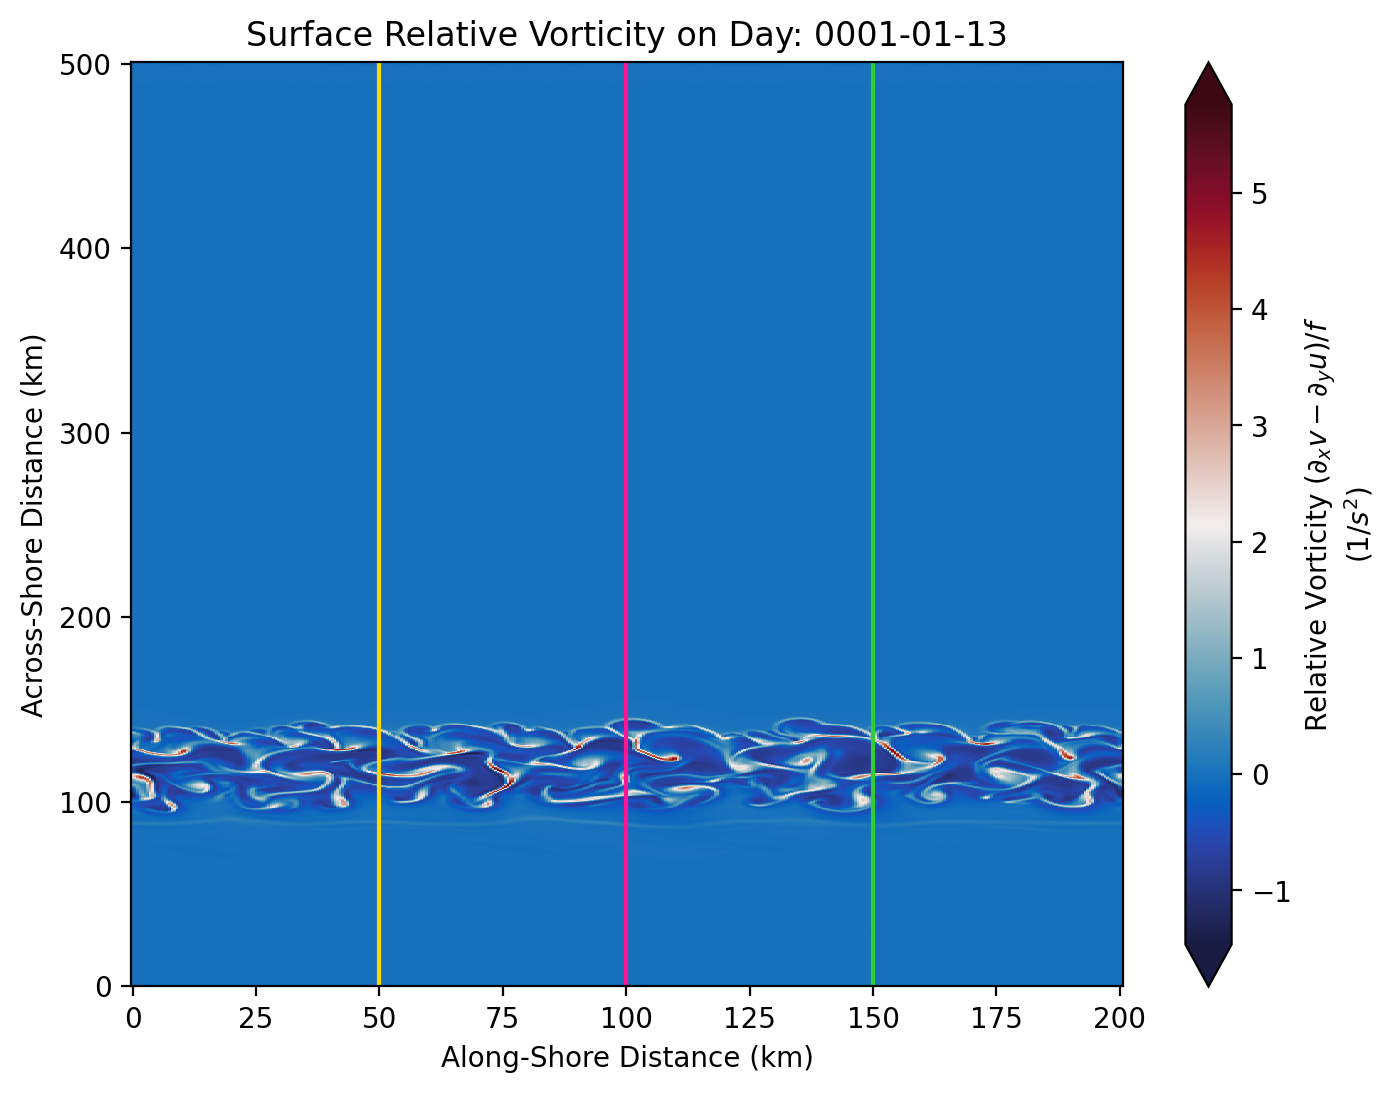

In [15]:
# Plot the domain and pick the cross sections we want to look at 

# Set the time index to look at 
time_idx1 = 150

# Set the levels 
lev_vort = np.arange(-1, 1, 0.01)

# Make the figure 
fig, ax  = plt.subplots(figsize=(8,6), dpi=200)

# Plot vorticity to pick our cross-sections 
p1 = ax.pcolormesh(x_rho/1000, y_rho/1000, rv[time_idx1, -1, :, :],
               cmap=cmo.balance)

# Add a colorbar
fig.colorbar(p1, extend='both').set_label('Relative Vorticity $(\partial_x v - \partial_y u)/f$ \n($1/s^{2}$)')

# Plot transects 
plt.axvline(x_rho[x_tran1]/1000, color='gold', linewidth=1.5, label='Transect 1')
plt.axvline(x_rho[x_tran2]/1000, color='deeppink', linewidth=1.5, label='Transect 2')
plt.axvline(x_rho[x_tran3]/1000, color='limegreen', linewidth=1.5, label='Transect 3')

# Label the axes
ax.set_xlabel('Along-Shore Distance (km)')
ax.set_ylabel('Across-Shore Distance (km)')
ax.set_title('Surface Relative Vorticity on Day: ' + str(ds.ocean_time.values[time_idx1])[:10])


In [16]:
# Probably don't want to plot to the end of the domain but stick around the jet area 
# and maybe nearshore of that, too, just to see what's happening in shallow
# depths 

## Salinity, Temperature, and Density

In [17]:
ds.z_rho

<xarray.DataArray 'z_rho' (ocean_time: 1440, s_rho: 40, eta_rho: 1002,
                           xi_rho: 402)> Size: 186GB
dask.array<transpose, shape=(1440, 40, 1002, 402), dtype=float64, chunksize=(1, 40, 1002, 402), chunktype=numpy.ndarray>
Coordinates:
  * s_rho       (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
    x_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
    z_rho       (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
Attributes:
    long_name:      depth of RHO-points
    time:           ocean_time
    field:          z_rho, scalar, series
    units:          m
    positive:       up
    standard_name:  depth

[None, None, None, None, None]

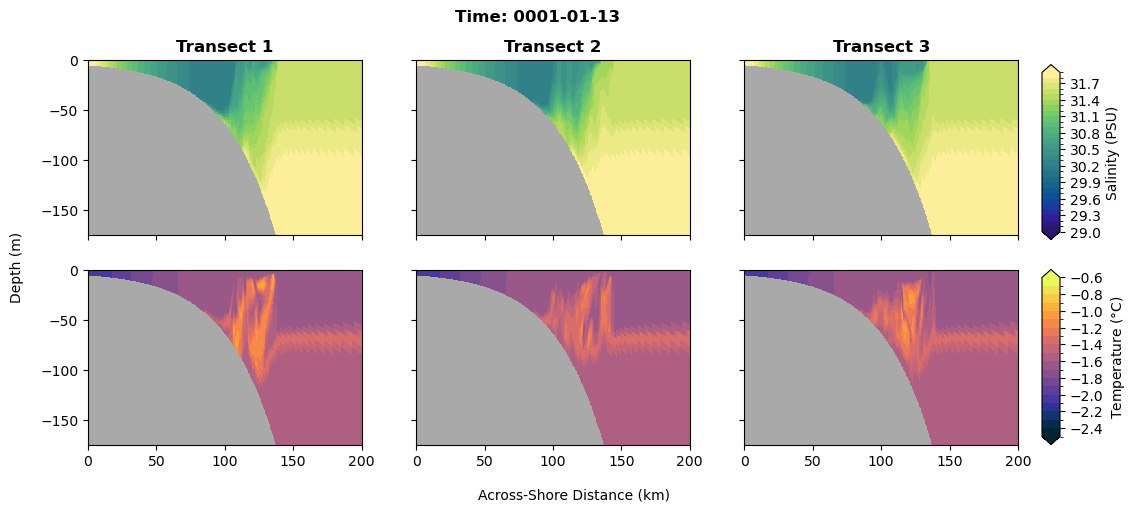

In [ ]:
# Plot the salinity and tempature at these transects
# at that time index

# Set the levels
lev_salt = np.arange(29, 32, 0.1)
lev_temp = np.arange(-2.5, -0.5, 0.1)

# Set the colormaps
cmap_salt = cmo.haline
cmap_temp = cmo.thermal

# Define the normalization instance
# ncolors specifies how many color intervals the cmap should be split into
norm_salt = BoundaryNorm(lev_salt, ncolors=cmap_salt.N, clip=True)
norm_temp = BoundaryNorm(lev_temp, ncolors=cmap_temp.N, clip=True)

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(12,5))

# Plot salinity
# Transect 1
p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.salt[time_idx1,:,:,x_tran1],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 2
p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.salt[time_idx1,:,:,x_tran2],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 3
p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.salt[time_idx1,:,:,x_tran3],
                        cmap=cmap_salt, norm=norm_salt)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
fig.colorbar(p3,ax=ax,extend='both', label='Salinity (PSU)',
             pad=0.03, cax=cbar_ax1)


# Plot temperature 
# Transect 1
p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.temp[time_idx1,:,:,x_tran1],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 2
p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.temp[time_idx1,:,:,x_tran2],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 3
p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.temp[time_idx1,:,:,x_tran3],
                        cmap=cmap_temp, norm=norm_temp)
# Add colorbar
#plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
fig.colorbar(p6,ax=ax,extend='both', label='Temperature ($\degree$C)',
             pad=0.03, cax=cbar_ax2)

# Add density contours...

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')

# Label the plots/axes
ax[0,0].set_title('Transect 1', weight='bold')
ax[0,1].set_title('Transect 2', weight='bold')
ax[0,2].set_title('Transect 3', weight='bold')
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[:10], weight='bold')
fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)


In [19]:
# Calculate density
roms_density = xroms.roms_seawater.density(ds.temp, ds.salt, z=None)

In [20]:
roms_density[time_idx1,:,:,x_tran1].max().values

array(1036.58666224)

[None, None, None, None, None]

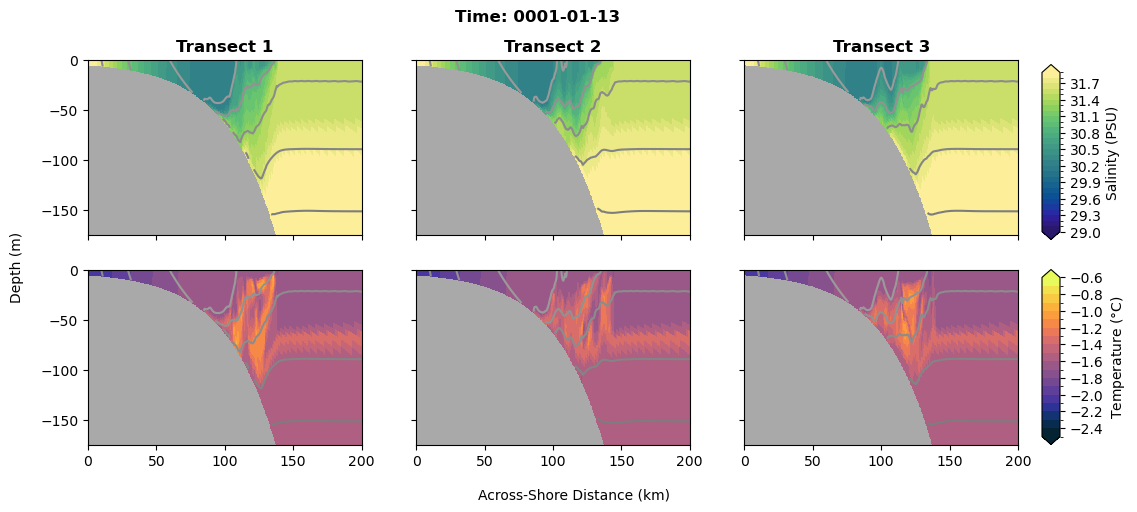

In [21]:
# Make same plot but with density contours
# Set the levels
lev_salt = np.arange(29, 32, 0.1)
lev_temp = np.arange(-2.5, -0.5, 0.1)
lev_dens = np.arange(1015, 1035, 0.5)

# Set the colormaps 
cmap_salt = cmo.haline
cmap_temp = cmo.thermal

# Define the normalization instance
# ncolors specifies how many color intervals the cmap should be split into
norm_salt = BoundaryNorm(lev_salt, ncolors=cmap_salt.N, clip=True)
norm_temp = BoundaryNorm(lev_temp, ncolors=cmap_temp.N, clip=True)

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(12,5))

# Plot salinity
# Transect 1
p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.salt[time_idx1,:,:,x_tran1],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 2
p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.salt[time_idx1,:,:,x_tran2],
                        cmap=cmap_salt, norm=norm_salt)
# Transect 3
p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.salt[time_idx1,:,:,x_tran3],
                        cmap=cmap_salt, norm=norm_salt)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
fig.colorbar(p3,ax=ax,extend='both', label='Salinity (PSU)',
             pad=0.03, cax=cbar_ax1)


# Plot temperature 
# Transect 1
p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.temp[time_idx1,:,:,x_tran1],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 2
p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.temp[time_idx1,:,:,x_tran2],
                        cmap=cmap_temp, norm=norm_temp)
# Transect 3
p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.temp[time_idx1,:,:,x_tran3],
                        cmap=cmap_temp, norm=norm_temp)
# Add colorbar
#plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
fig.colorbar(p6,ax=ax,extend='both', label='Temperature ($\degree$C)',
             pad=0.03, cax=cbar_ax2)

# Set limits to focus on the jet
# Loop through columns
for r in range(3):
    # Loop through rows
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)

        # Set the facecolor
        ax[j,r].set_facecolor('darkgray')

        # Plot density contours
        if r == 0: 
            y_2d = np.tile(y_rho, (ds.z_rho[time_idx1,:,:,x_tran1].shape[0], 1))
            c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx1,:,:,x_tran1], roms_density[time_idx1,:,:,x_tran1],
                 levels=lev_dens, cmap='Greys')
            ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
        if r == 1: 
            y_2d = np.tile(y_rho, (ds.z_rho[time_idx1,:,:,x_tran2].shape[0], 1))
            c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx1,:,:,x_tran2], roms_density[time_idx1,:,:,x_tran2],
                 levels=lev_dens, cmap='Greys')
            ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
        if r == 2:
            y_2d = np.tile(y_rho, (ds.z_rho[time_idx1,:,:,x_tran3].shape[0], 1))
            c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx1,:,:,x_tran3], roms_density[time_idx1,:,:,x_tran3],
                 levels=lev_dens, cmap='Greys')
            ax[j,r].clabel(c1, inline=True, fmt='%1.2f')



# Label the plots/axes
ax[0,0].set_title('Transect 1', weight='bold')
ax[0,1].set_title('Transect 2', weight='bold')
ax[0,2].set_title('Transect 3', weight='bold')
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[:10], weight='bold')
fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)


In [22]:
# Definitely make movies of this because this is looking crazzzyyyyy

In [ ]:
# Make a movie of the verison with density 
# Define a function to make the plots
# Now define function to plot the movie
def plot_salt_temp_trans(time_idx):
    i = time_idx // 1
    #print('i: ', i)
    #print('time_idx: ', time_idx)

    # Set the levels
    lev_salt = np.arange(29, 32, 0.1)
    lev_temp = np.arange(-2.5, -0.5, 0.1)
    lev_dens = np.arange(1015, 1035, 0.5)

    # Set the colormaps 
    cmap_salt = cmo.haline
    cmap_temp = cmo.thermal

    # Define the normalization instance
    # ncolors specifies how many color intervals the cmap should be split into
    norm_salt = BoundaryNorm(lev_salt, ncolors=cmap_salt.N, clip=True)
    norm_temp = BoundaryNorm(lev_temp, ncolors=cmap_temp.N, clip=True)

    # Make the figure 
    fig, ax = plt.subplots(2, 3, figsize=(12,5))

    # Plot salinity
    # Transect 1
    p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], ds.salt[time_idx,:,:,x_tran1],
                            cmap=cmap_salt, norm=norm_salt)
    # Transect 2
    p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran2], ds.salt[time_idx,:,:,x_tran2],
                            cmap=cmap_salt, norm=norm_salt)
    # Transect 3
    p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran3], ds.salt[time_idx,:,:,x_tran3],
                            cmap=cmap_salt, norm=norm_salt)
    # Add colorbar
    #plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
    cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
    fig.colorbar(p3,ax=ax,extend='both', label='Salinity (PSU)',
                pad=0.03, cax=cbar_ax1)


    # Plot temperature 
    # Transect 1
    p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran1], ds.temp[time_idx,:,:,x_tran1],
                            cmap=cmap_temp, norm=norm_temp)
    # Transect 2
    p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran2], ds.temp[time_idx,:,:,x_tran2],
                            cmap=cmap_temp, norm=norm_temp)
    # Transect 3
    p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx,:,:,x_tran3], ds.temp[time_idx,:,:,x_tran3],
                            cmap=cmap_temp, norm=norm_temp)
    # Add colorbar
    #plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
    cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
    fig.colorbar(p6,ax=ax,extend='both', label='Temperature ($\degree$C)',
                pad=0.03, cax=cbar_ax2)

    # Set limits to focus on the jet
    # Loop through columns
    for r in range(3):
        # Loop through rows
        for j in range(2):
            # Set the limits
            ax[j,r].set_xlim(0,200)
            ax[j,r].set_ylim(-175,0)

            # Set the facecolor
            ax[j,r].set_facecolor('darkgray')

            # Plot density contours
            if r == 0: 
                y_2d = np.tile(y_rho, (ds.z_rho[time_idx,:,:,x_tran1].shape[0], 1))
                c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx,:,:,x_tran1], roms_density[time_idx,:,:,x_tran1],
                    levels=lev_dens, cmap='Greys')
                ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
            if r == 1: 
                y_2d = np.tile(y_rho, (ds.z_rho[time_idx,:,:,x_tran2].shape[0], 1))
                c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx,:,:,x_tran2], roms_density[time_idx,:,:,x_tran2],
                    levels=lev_dens, cmap='Greys')
                ax[j,r].clabel(c1, inline=True, fmt='%1.2f')
            if r == 2:
                y_2d = np.tile(y_rho, (ds.z_rho[time_idx,:,:,x_tran3].shape[0], 1))
                c1 = ax[j,r].contour(y_2d/1000, ds.z_rho[time_idx,:,:,x_tran3], roms_density[time_idx,:,:,x_tran3],
                    levels=lev_dens, cmap='Greys')
                ax[j,r].clabel(c1, inline=True, fmt='%1.2f')



    # Label the plots/axes
    ax[0,0].set_title('Transect 1', weight='bold')
    ax[0,1].set_title('Transect 2', weight='bold')
    ax[0,2].set_title('Transect 3', weight='bold')
    fig.suptitle('Time: ' + str(ds.ocean_time[time_idx].values)[:10], weight='bold')
    fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
    fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

    # Hide some axis labels 
    plt.setp(ax[0,1].get_xticklabels(), visible=False)
    plt.setp(ax[0,1].get_yticklabels(), visible=False)
    plt.setp(ax[0,2].get_xticklabels(), visible=False)
    plt.setp(ax[0,2].get_yticklabels(), visible=False)
    plt.setp(ax[0,0].get_xticklabels(), visible=False)
    plt.setp(ax[1,1].get_yticklabels(), visible=False)
    plt.setp(ax[1,2].get_yticklabels(), visible=False)

    # Comment this out if you are printing a lot of frames... jupyter will be unhappy
    #print(f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/Surf_temp_salt_vort_ice/Plots01/surf_temp_salt_aice_icethick_rvort_tnum_{i}.png')
   
    plt.savefig(
        f'/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Movies/Salt_temp_dens/Plots01/salt_temp_dens_trans_500m_span_500km_const_u3c4_keps_{i}.png',
        dpi=200, bbox_inches='tight'
    )
    plt.close(fig)  # Close to avoid memory leaks


In [24]:
# Call the function to make the plots for the movie
Parallel(n_jobs=4)(delayed(plot_salt_temp_trans)(time_idx) for time_idx in range(0, len(ds.ocean_time), 1))

/tmp/ipykernel_1651908/620451440.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
/tmp/ipykernel_1651908/620451440.py:31: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
/tmp/ipykernel_1651908/620451440.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
/tmp/ipykernel_1651908/620451440.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are 

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

## Velocities 

In [ ]:
# Plot transects of the velocities (particularly u)
# at these three transects 


TypeError: Dimensions of C (40, 1001) should be one smaller than X(1002) and Y(40) while using shading='flat' see help(pcolormesh)

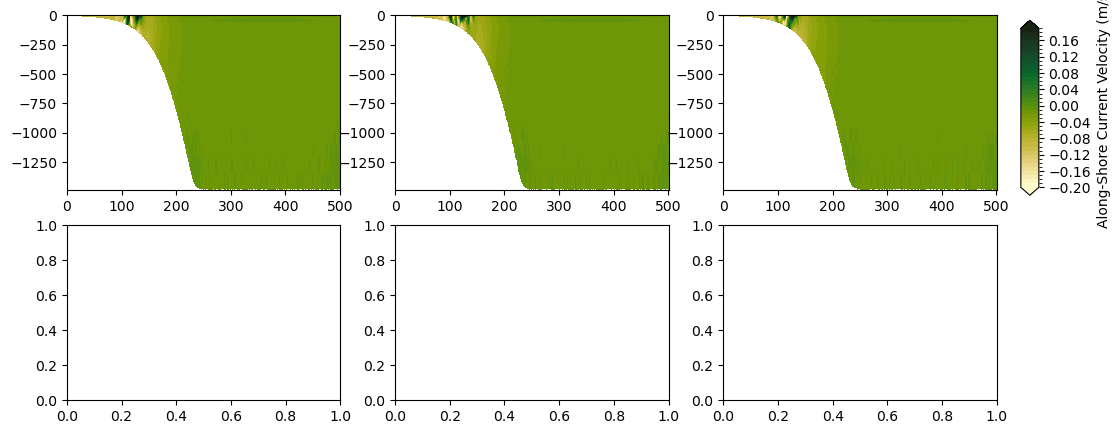

In [25]:
# Set the levels
lev_cur = np.arange(-0.2, 0.2, 0.01)

# Set the colormaps
cmap_cur = cmo.speed

# Define the normalization instance
# ncolors specifies how many color intervals the cmap should be split into
norm_cur = BoundaryNorm(lev_cur, ncolors=cmap_cur.N, clip=True)

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(12,5))

# Plot u
# Transect 1
p1 = ax[0,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.u[time_idx1,:,:,x_tran1],
                        cmap=cmap_cur, norm=norm_cur)
# Transect 2
p2 = ax[0,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.u[time_idx1,:,:,x_tran2],
                        cmap=cmap_cur, norm=norm_cur)
# Transect 3
p3 = ax[0,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.u[time_idx1,:,:,x_tran3],
                        cmap=cmap_cur, norm=norm_cur)
# Add colorbar
#plt.colorbar(p3, ax=[ax[0,0], ax[0,1], ax[0,2]], extend='both').set_label('Salinity (PSU)')
cbar_ax1 = fig.add_axes([0.92,0.52,0.015,0.35])
fig.colorbar(p3,ax=ax,extend='both', label='Along-Shore Current Velocity (m/s)',
             pad=0.03, cax=cbar_ax1)


# Plot v 
# Transect 1
p4 = ax[1,0].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran1], ds.v[time_idx1,:,:,x_tran1],
                        cmap=cmap_cur, norm=norm_cur)
# Transect 2
p5 = ax[1,1].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran2], ds.v[time_idx1,:,:,x_tran2],
                        cmap=cmap_cur, norm=norm_cur)
# Transect 3
p6 = ax[1,2].pcolormesh(y_rho/1000, ds.z_rho[time_idx1,:,:,x_tran3], ds.v[time_idx1,:,:,x_tran3],
                        cmap=cmap_cur, norm=norm_cur)
# Add colorbar
#plt.colorbar(p6, ax=[ax[1,0], ax[1,1], ax[1,2]], extend='both').set_label('Temperature (C)')
cbar_ax2 = fig.add_axes([0.92,0.11,0.015,0.35])
fig.colorbar(p6,ax=ax,extend='both', label='Across-Shore Current Velocity (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add density contours...

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')

# Label the plots/axes
ax[0,0].set_title('Transect 1', weight='bold')
ax[0,1].set_title('Transect 2', weight='bold')
ax[0,2].set_title('Transect 3', weight='bold')
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[:10], weight='bold')
fig.text(0.45, 0.001, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)

## Mixing & Eddy Viscosity/Diffusivity